In [1]:
import os
import pandas as pd

In [2]:
# 1. Define the relative path to the new Kaggle CSV file
# Adjust the filename 'player_stats.csv' if the downloaded file has a slightly different name
csv_filename = "player_stats.csv"
data_path = os.path.join("..", "data", "raw", csv_filename)

try:
    # 2. Load the dataset into a Pandas DataFrame
    df_players = pd.read_csv(data_path)
    print("Dataset loaded successfully!")
    print("-" * 50)

    # 3. Inspect the shape of the data (Rows, Columns)
    print(f"Dataset Dimensions: {df_players.shape[0]} rows, {df_players.shape[1]} columns")
    print("-" * 50)

    # 4. Display the first 5 records to verify the content
    print("First 5 rows of the dataset:")
    print(df_players.head())
    print("-" * 50)

    # 5. Print all available column names to identify our metrics
    print("Available columns in this dataset:")
    print(df_players.columns.tolist())

except FileNotFoundError:
    print(f"Error: The file '{csv_filename}' was not found in '../data/raw/'. Please check the filename and path.")
except Exception as e:
    print(f"An error occurred: {str(e)}")

Dataset loaded successfully!
--------------------------------------------------
Dataset Dimensions: 35076 rows, 19 columns
--------------------------------------------------
First 5 rows of the dataset:
   player_id                name  season position  games  goals  shots  time  \
0          1  Christian Mathenia    2018       GK     22      0      0  1933   
1          1  Christian Mathenia    2017       GK     24      0      0  2160   
2          1  Christian Mathenia    2016       GK     14      0      0  1260   
3          1  Christian Mathenia    2015       GK     33      0      0  2970   
4          2       György Garics    2015       DR     21      0      3  1796   

         xG  assists        xA  key_passes          team  yellow  red  npg  \
0  0.000000        0  0.102488           1     Nuernberg       2    0    0   
1  0.000000        0  0.027247           1  Hamburger SV       2    0    0   
2  0.000000        0  0.015250           1  Hamburger SV       1    0    0   
3  0

In [3]:
# 6. Define the relative path and load the dataset again to ensure a clean slate
csv_filename = "player_stats.csv"
data_path = os.path.join("..", "data", "raw", csv_filename)
df_raw = pd.read_csv(data_path)

print(f"Original dataset records: {df_raw.shape[0]}")

# 7. Check for missing values across critical columns
print("\nMissing values per column:")
print(df_raw[["name", "season", "position", "time", "goals", "xG", "xA"]].isnull().sum())

# 8. Apply the Minutes-Threshold Law (Keep players with 900+ minutes played)
# This eliminates players with extreme but unsustainable 'Per 90' stats due to low sample sizes
min_minutes = 900
df_filtered = df_raw[df_raw["time"] >= min_minutes].copy()

# 9. Remove Goalkeepers (GK) from our attacking and playmaking benchmark
df_filtered = df_filtered[df_filtered["position"] != "GK"]

print("\n" + "-"*50)
print(f"Dataset records after filtering (Minutes >= {min_minutes} & No GKs): {df_filtered.shape[0]}")
print("-"*50)

# 10. Display data types to verify they are ready for mathematical operations
print("\nData types of selected columns:")
print(df_filtered[["games", "goals", "shots", "time", "xG", "xA"]].dtypes)

Original dataset records: 35076

Missing values per column:
name        0
season      0
position    0
time        0
goals       0
xG          0
xA          0
dtype: int64

--------------------------------------------------
Dataset records after filtering (Minutes >= 900 & No GKs): 17044
--------------------------------------------------

Data types of selected columns:
games      int64
goals      int64
shots      int64
time       int64
xG       float64
xA       float64
dtype: object


In [4]:
# 11. Create Per 90 columns for traditional and advanced metrics
df_filtered["goals_per_90"] = (df_filtered["goals"] / df_filtered["time"]) * 90
df_filtered["assists_per_90"] = (df_filtered["assists"] / df_filtered["time"]) * 90
df_filtered["shots_per_90"] = (df_filtered["shots"] / df_filtered["time"]) * 90
df_filtered["key_passes_per_90"] = (df_filtered["key_passes"] / df_filtered["time"]) * 90
df_filtered["xG_per_90"] = (df_filtered["xG"] / df_filtered["time"]) * 90
df_filtered["xA_per_90"] = (df_filtered["xA"] / df_filtered["time"]) * 90

# 12. Verify that the new columns have been added to the DataFrame
print("Updated Column List:")
print(df_filtered.columns.tolist())
print("-" * 60)

# 13. Preview a sample of the newly created columns for the first 5 rows
columns_to_show = ["name", "season", "goals_per_90", "xG_per_90", "assists_per_90", "xA_per_90"]
print("Sample of normalized Per 90 data:")
print(df_filtered[columns_to_show].head())

Updated Column List:
['player_id', 'name', 'season', 'position', 'games', 'goals', 'shots', 'time', 'xG', 'assists', 'xA', 'key_passes', 'team', 'yellow', 'red', 'npg', 'npxG', 'xGChain', 'xGBuildup', 'goals_per_90', 'assists_per_90', 'shots_per_90', 'key_passes_per_90', 'xG_per_90', 'xA_per_90']
------------------------------------------------------------
Sample of normalized Per 90 data:
              name  season  goals_per_90  xG_per_90  assists_per_90  xA_per_90
4    György Garics    2015      0.000000   0.002232        0.000000   0.014641
6   Luca Caldirola    2023      0.042056   0.030420        0.042056   0.020624
7   Luca Caldirola    2022      0.113636   0.051605        0.000000   0.024322
8   Luca Caldirola    2020      0.115385   0.030717        0.000000   0.009094
11  Luca Caldirola    2015      0.000000   0.074337        0.029412   0.038843


In [5]:
# 14. Filter and isolate Lionel Messi's career data
# We check if his exact string match exists and look at his historical footprint
df_messi = df_filtered[df_filtered["name"] == "Lionel Messi"]

print("=" * 60)
print("LIONEL MESSI'S HISTORICAL SEASONS IN THIS DATASET:")
print("=" * 60)
columns_to_check = ["season", "team", "games", "time", "goals", "assists"]
print(df_messi[columns_to_check].sort_values(by="season"))
print("-" * 60)
print(f"Total filtered seasons found for Messi: {len(df_messi)}")


# 15. Export the fully refined and complete dataset to our 'processed' directory
# This ensures we don't have to re-run the cleaning logic in future notebooks
processed_output_path = os.path.join(
    "..", "data", "processed", "understat_cleaned_data.csv"
)
df_filtered.to_csv(processed_output_path, index=False)

print("\n" + "=" * 60)
print(f"SUCCESS: Refined master dataset exported to: {processed_output_path}")
print("=" * 60)

LIONEL MESSI'S HISTORICAL SEASONS IN THIS DATASET:
       season                 team  games  time  goals  assists
10340    2014            Barcelona     38  3374     43       18
10339    2015            Barcelona     33  2726     26       16
10338    2016            Barcelona     34  2832     37        9
10337    2017            Barcelona     36  2995     34       12
10336    2018            Barcelona     34  2704     36       13
10335    2019            Barcelona     33  2876     25       20
10334    2020            Barcelona     35  3017     30        9
10333    2021  Paris Saint Germain     26  2155      6       13
10332    2022  Paris Saint Germain     32  2855     16       16
------------------------------------------------------------
Total filtered seasons found for Messi: 9

SUCCESS: Refined master dataset exported to: ..\data\processed\understat_cleaned_data.csv


In [6]:
# 16. Load the cleaned dataset from the processed directory
processed_data_path = os.path.join(
    "..", "data", "processed", "understat_cleaned_data.csv"
)
df = pd.read_csv(processed_data_path)

# 17. Isolate Lionel Messi's data
df_messi = df[df["name"] == "Lionel Messi"].copy()

# 18. Calculate combined actual and expected attacking metrics per 90 minutes
df_messi["actual_contributions_per_90"] = (
    df_messi["goals_per_90"] + df_messi["assists_per_90"]
)
df_messi["expected_contributions_per_90"] = (
    df_messi["xG_per_90"] + df_messi["xA_per_90"]
)

# 19. Select and reorder relevant columns for a clean output
analysis_columns = [
    "season",
    "team",
    "games",
    "goals_per_90",
    "assists_per_90",
    "actual_contributions_per_90",
    "expected_contributions_per_90",
]

# 20. Sort by actual contributions to find his most efficient season
df_messi_sorted = df_messi[analysis_columns].sort_values(
    by="actual_contributions_per_90", ascending=False
)

print("=" * 80)
print("LIONEL MESSI'S SEASONS RANKED BY ATTACKING OUTPUT PER 90 MINS")
print("=" * 80)
print(df_messi_sorted.to_string(index=False))

LIONEL MESSI'S SEASONS RANKED BY ATTACKING OUTPUT PER 90 MINS
 season                team  games  goals_per_90  assists_per_90  actual_contributions_per_90  expected_contributions_per_90
   2018           Barcelona     34      1.198225        0.432692                     1.630917                       1.375706
   2014           Barcelona     38      1.147007        0.480142                     1.627149                       1.427189
   2016           Barcelona     34      1.175847        0.286017                     1.461864                       1.297891
   2019           Barcelona     33      0.782337        0.625869                     1.408206                       1.171722
   2015           Barcelona     33      0.858401        0.528247                     1.386647                       1.418777
   2017           Barcelona     36      1.021703        0.360601                     1.382304                       1.323607
   2020           Barcelona     35      0.894929        0.26847

In [7]:
# 21. Apply the contribution calculations to the entire dataset for a fair benchmark
df["actual_contributions_per_90"] = df["goals_per_90"] + df["assists_per_90"]
df["expected_contributions_per_90"] = df["xG_per_90"] + df["xA_per_90"]

# 22. Filter the dataset for the 2018 season only
df_2018 = df[df["season"] == 2018].copy()

# 23. Extract the top 10 players in Europe based on their attacking efficiency per 90
top_10_2018 = df_2018[
    [
        "name",
        "team",
        "games",
        "goals_per_90",
        "assists_per_90",
        "actual_contributions_per_90",
    ]
].sort_values(by="actual_contributions_per_90", ascending=False).head(10)

print("=" * 95)
print("TOP 10 MOST EFFICIENT PLAYERS IN EUROPE (2018 SEASON) - PER 90 MINUTES")
print("=" * 95)
print(top_10_2018.to_string(index=False))

TOP 10 MOST EFFICIENT PLAYERS IN EUROPE (2018 SEASON) - PER 90 MINUTES
                name                team  games  goals_per_90  assists_per_90  actual_contributions_per_90
        Lionel Messi           Barcelona     34      1.198225        0.432692                     1.630917
Kylian Mbappe-Lottin Paris Saint Germain     29      1.272494        0.269923                     1.542416
              Neymar Paris Saint Germain     17      0.935551        0.436590                     1.372141
        Paco Alcácer   Borussia Dortmund     26      1.371719        0.000000                     1.371719
      Edinson Cavani Paris Saint Germain     21      0.966011        0.268336                     1.234347
       Dries Mertens              Napoli     35      0.641425        0.440980                     1.082405
       Sergio Agüero     Manchester City     33      0.751491        0.286282                     1.037773
          Iago Aspas          Celta Vigo     27      0.793651        0.23

In [8]:
# 24. Isolate Lionel Messi's clean dataset from our master data
df_messi_career = df[df["name"] == "Lionel Messi"].copy()

# 25. Calculate Cumulative Career Totals (Raw Counts)
total_games = df_messi_career["games"].sum()
total_mins = df_messi_career["time"].sum()
total_goals = df_messi_career["goals"].sum()
total_xG = df_messi_career["xG"].sum()
total_assists = df_messi_career["assists"].sum()
total_xA = df_messi_career["xA"].sum()

# 26. Calculate the Efficiency Premiums (Actual minus Expected)
# Positive value means the player outperforms the mathematical model
finishing_premium = total_goals - total_xG
playmaking_premium = total_assists - total_xA

# 27. Print the comprehensive career efficiency report
print("=" * 65)
print("LIONEL MESSI'S CAREER EFFICIENCY REPORT (UNDERSTAT DATA)")
print("=" * 65)
print(f"Total Matches Analyzed : {total_games}")
print(f"Total Minutes Played   : {total_mins:,} mins (approx. {total_mins/90:.1f} full 90s)")
print("-" * 65)
print(f"Actual Goals Scored    : {total_goals}")
print(f"Expected Goals (xG)    : {total_xG:.2f}")
print(f"Finishing Premium      : +{finishing_premium:.2f} goals over expectation")
print("-" * 65)
print(f"Actual Assists Provided: {total_assists}")
print(f"Expected Assists (xA)  : {total_xA:.2f}")
print(f"Playmaking Premium     : +{playmaking_premium:.2f} assists over expectation")
print("=" * 65)

LIONEL MESSI'S CAREER EFFICIENCY REPORT (UNDERSTAT DATA)
Total Matches Analyzed : 301
Total Minutes Played   : 25,534 mins (approx. 283.7 full 90s)
-----------------------------------------------------------------
Actual Goals Scored    : 253
Expected Goals (xG)    : 219.89
Finishing Premium      : +33.11 goals over expectation
-----------------------------------------------------------------
Actual Assists Provided: 126
Expected Assists (xA)  : 129.81
Playmaking Premium     : +-3.81 assists over expectation


SUCCESS: Chart successfully saved at: ..\figures\messi_efficiency_trend.png


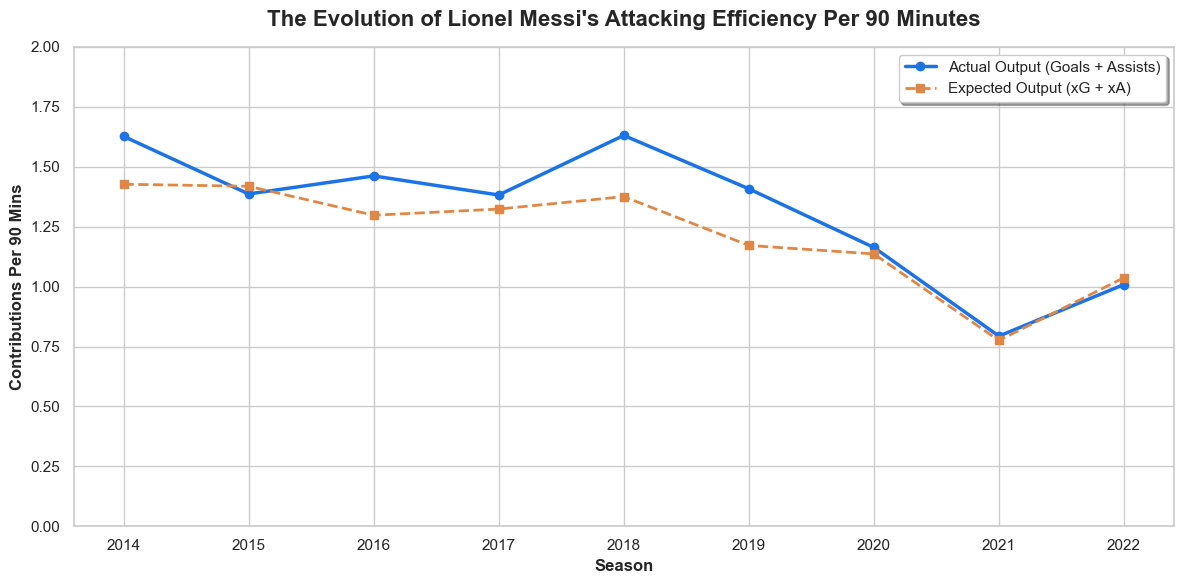

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 28. Set the aesthetic style for the plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 29. Sort Messi's data chronologically by season
df_messi_trend = df_messi.sort_values(by="season")

# 30. Plot Actual vs Expected Contributions per 90 over the seasons
plt.plot(df_messi_trend['season'].astype(str), df_messi_trend['actual_contributions_per_90'], 
         marker='o', linewidth=2.5, color='#1a73e8', label='Actual Output (Goals + Assists)')

plt.plot(df_messi_trend['season'].astype(str), df_messi_trend['expected_contributions_per_90'], 
         marker='s', linewidth=2, color='#e28743', linestyle='--', label='Expected Output (xG + xA)')

# 31. Customize titles and labels for a professional look
plt.title("The Evolution of Lionel Messi's Attacking Efficiency Per 90 Minutes", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Season", fontsize=12, fontweight='bold')
plt.ylabel("Contributions Per 90 Mins", fontsize=12, fontweight='bold')
plt.ylim(0, 2.0)

# 32. Add a shadow legend and layout adjustments
plt.legend(loc="upper right", fontsize=11, frameon=True, shadow=True)
plt.tight_layout()

# 33. FIX: Create the 'figures' directory automatically if it does not exist
output_dir = os.path.join("..", "figures")
os.makedirs(output_dir, exist_ok=True)

# 34. Save the visualization safely
output_chart_path = os.path.join(output_dir, "messi_efficiency_trend.png")
plt.savefig(output_chart_path, dpi=300)
print(f"SUCCESS: Chart successfully saved at: {output_chart_path}")
plt.show()

SUCCESS: Benchmark chart saved at: ..\figures\europe_top_10_2018_benchmark.png


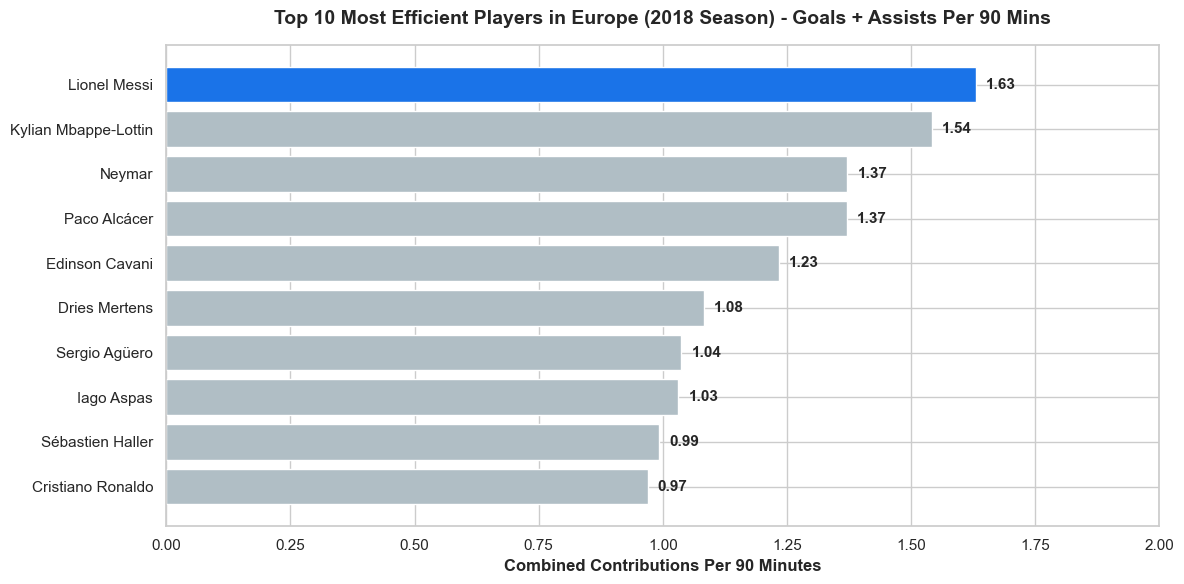

In [10]:
# 35. Prepare and sort the top 10 data so the highest is at the top of the horizontal chart
top_10_plot_data = top_10_2018.sort_values(by="actual_contributions_per_90", ascending=True)

plt.figure(figsize=(12, 6))

# 36. Highlight rule: Create a color list where Messi gets a distinct vibrant color, others get neutral gray
bar_colors = ['#1a73e8' if player == 'Lionel Messi' else '#b0bec5' for player in top_10_plot_data['name']]

# 37. Create the horizontal bar chart
bars = plt.barh(top_10_plot_data['name'], top_10_plot_data['actual_contributions_per_90'], color=bar_colors)

# 28. Add data labels at the end of each bar for direct scannability
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.02, bar.get_y() + bar.get_height()/2, f'{width:.2f}', 
             va='center', ha='left', fontsize=11, fontweight='bold')

# 39. Fine-tune labels and titles
plt.title("Top 10 Most Efficient Players in Europe (2018 Season) - Goals + Assists Per 90 Mins", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Combined Contributions Per 90 Minutes", fontsize=12, fontweight='bold')
plt.xlim(0, 2.0)  # Give breathing room for the text labels

# 40. Adjust layout and save safely into our established figures directory
plt.tight_layout()
output_bar_path = os.path.join("..", "figures", "europe_top_10_2018_benchmark.png")
plt.savefig(output_bar_path, dpi=300)
print(f"SUCCESS: Benchmark chart saved at: {output_bar_path}")
plt.show()